In [2]:
import os
import ast
import git
import boto3
import nbformat
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import BedrockEmbeddings

AWS_ACCESS_KEY_ID = os.environ.get("AWS_ACCESS_KEY_ID")
AWS_SECRET_ACCESS_KEY = os.environ.get("AWS_SECRET_ACCESS_KEY")
AWS_REGION_NAME = os.environ.get("AWS_REGION_NAME", "us-east-1") 

bedrock_client=boto3.client(
    "bedrock-runtime",
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    region_name=AWS_REGION_NAME
)

def clone_repo(repo_url):
    repo_name=repo_url.split("/")[-1].replace(".git","")
    if not os.path.exists("repos"):
        os.makedirs("repos", exist_ok=True)
    local_path=os.path.join("repos",repo_name)
    if not os.path.exists(local_path):
        git.Repo.clone_from(repo_url, local_path)
    return local_path


def extract_code_units(file_path):
    units = []
    if file_path.endswith(".py"):
        with open(file_path, "r", encoding="utf-8") as f:
            code = f.read()
        try:
            tree = ast.parse(code)
            for node in ast.walk(tree):
                if isinstance(node, (ast.FunctionDef, ast.ClassDef)):
                    start_line = node.lineno
                    end_line = node.end_lineno
                    chunk = "\n".join(code.splitlines()[start_line-1:end_line])
                    metadata = {"file": file_path, "name": node.name, "type": type(node).__name__}
                    units.append((chunk, metadata))
        except SyntaxError:
            metadata = {"file": file_path, "name": "unknown", "type": "file"}
            units.append((code, metadata))
    
    elif file_path.endswith(".ipynb"):
        with open(file_path, "r", encoding="utf-8") as f:
            notebook = nbformat.read(f, as_version=4)
        for cell in notebook.cells:
            if cell.cell_type == "code":
                code = cell.source
                try:
                    tree = ast.parse(code)
                    for node in ast.walk(tree):
                        if isinstance(node, (ast.FunctionDef, ast.ClassDef)):
                            chunk = code
                            metadata = {"file": file_path, "name": node.name, "type": type(node).__name__, "cell_index": notebook.cells.index(cell)}
                            units.append((chunk, metadata))
                except SyntaxError:
                    metadata = {"file": file_path, "name": "unknown", "type": "cell", "cell_index": notebook.cells.index(cell)}
                    units.append((code, metadata))
    
    elif file_path.endswith((
        ".c", ".cpp",  
        ".js", ".ts", ".tsx", ".jsx", 
        ".go",  
        ".java",  
        ".rb",  
        ".php",  
        ".swift",   
        ".sh", ".bash",  
        ".ps1",  
        ".r", ".R",   
        ".yaml", ".yml",  
        ".json",  
        ".xml",  
        ".html", ".htm",  
        ".css", ".scss", ".sass",  
        ".sql",  
        ".dockerfile", ".Dockerfile",  
        ".md", ".markdown",
        ".makefile", ".Makefile", ".mk"
    )):
        with open(file_path, "r", encoding="utf-8") as f:
            code = f.read()
        metadata = {"file": file_path, "name": os.path.basename(file_path), "type": "file"}
        units.append((code, metadata))
    
    return units


def build_retriever(repo_url):
    local_path=clone_repo(repo_url)
    code_units=[]
    for root, _, files in os.walk(local_path):
        for file in files:
            file_path = os.path.join(root, file)
            units = extract_code_units(file_path)
            code_units.extend(units)
    
    if not code_units:
        raise ValueError("No code units found in the repository")
    embeddings = BedrockEmbeddings(
        model_id="amazon.titan-embed-text-v2:0",
        client=bedrock_client,
        model_kwargs={"dimensions": 512, "normalize": True}
    )
    chunks = [chunk for chunk, _ in code_units]
    metadata = [meta for _, meta in code_units]
    
    # Create vector store
    vector_store = FAISS.from_texts(
        texts=chunks,
        embedding=embeddings,
        metadatas=metadata
    )
    retriever = vector_store.as_retriever(search_type="mmr", search_kwargs={"k": 8})
    
    return retriever
    

In [3]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_aws import ChatBedrock

llm = ChatBedrock(model="amazon.nova-pro-v1:0")

template = """Answer the question based on the following context and the Chathistory. Especially take the latest question into consideration:

Chathistory: {history}

Context: {context}

Question: {question}
"""
prompt = ChatPromptTemplate.from_template(template)

rag_chain= prompt | llm



In [4]:
from typing import TypedDict,List
from langchain_core.messages import BaseMessage,AIMessage,HumanMessage,SystemMessage
from langgraph.graph import StateGraph,END
from pydantic import BaseModel,Field
from langchain_aws import ChatBedrock


class AgentState(TypedDict):
    messages:List[BaseMessage]
    on_topic=str
    rephrased_question=str
    proceed_to_generate=str
    rephrase_count=int
    question:HumanMessage
    code:list

class OffTopic(BaseModel):
    answer:str=Field(description="Question is from  specified topic ?If yes ->'yes' if not ->'no'")


def question_rewriter(state:AgentState):
    state["code"]=[]
    state["rephrased_question"] =[]
    state["rephrase_count"] = 0
    state["on_topic"] = "no"
    state["proceed_to_generate"] = "no"
    
    if state["messages"] is None:
        state["messages"] = []
    if state["question"] is None:
        state["question"] = state["question"].content

    if len(state["messages"]) > 1:
        conversation_history = state["messages"][:-1]
        current_question = state["question"].content
        messages=[
            SystemMessage(content="You are a helpful assistant that rewrites questions to be more specific and on-topic."),
            HumanMessage(content=current_question)
        ]
        messages.extend(conversation_history)
        rephrase_prompt=ChatPromptTemplate.from_messages(messages)
        llm=ChatBedrock(model="amazon.nova-pro-v1:0")
        response = llm.invoke(rephrase_prompt)
        better_question = response.content.strip()
        state["rephrased_question"] = better_question
    else:
        state["rephrased_question"] = state["question"].content
    return state

In [ ]:
def question_classifier(state:AgentState):
    message=[SystemMessage(content="""You are a helpful assistant that classifies questions based on Code." \
    "1)Code review" \
    "2)Code generation" \
    "3)Code explanation" \
    "4)Code summarization" \
    "5)About repo" \
    "6)About code" \
    """ ),HumanMessage(content=state["rephrased_question"])]
    classification_prompt=ChatPromptTemplate.from_messages(message)
    llm=ChatBedrock(model="amazon.nova-pro-v1:0")
    structured_llm=llm.with_structured_output(OffTopic)
    response = structured_llm.invoke(classification_prompt)
    state["on_topic"] = response.answer.strip().lower()
    return state

def on_topic_router(state:AgentState):
    if state["on_topic"] == "yes":
        return "retrieve"
    else :
        return "off_topic"
    
def retriever_node(state: AgentState):  # Renamed function
    code_units = retriever.invoke(state["rephrased_question"])  # This retriever is the global one
    state["code"] = code_units
    return state

class GradeCodeChunk:
    relevance:str=Field(description="Relevance of the code chunk to the question,if 'relevant' ->'relevant' else 'not relevant'")

def relevant_code_chunk(state:AgentState):
    message=[SystemMessage(content="You are code chunk relevance classifier on the basis of question asked by Human")]
    llm=ChatBedrock(model="amazon.nova-pro-v1:0")
    structured_llm=llm.with_structured_output(GradeCodeChunk)
    relevant_code_chunk=[]
    for code in state["code"]:
        human_message=HumanMessage(content=f"Is this {code} code chunk relevant to the question '{state['rephrased_question']}'?")
        relevant_code_chunk_prompt=ChatPromptTemplate.from_messages([message,human_message])
        response=structured_llm.invoke(relevant_code_chunk_prompt)
        if response.relevance.strip().lower() == "relevant":
            relevant_code_chunk.append(code)
    state["code"] = relevant_code_chunk
    if len(state["code"]) == 0:
        state["proceed_to_generate"] = "no"
    else:
        state["proceed_to_generate"] = "yes"
    return state


def router(state:AgentState):
    if state["rephrase_count"]>2:
        return "cannot_answer"
    elif state["proceed_to_generate"]:
        return "generate_answer"
    else:
        return "refine_question"

def refine_question(state: AgentState):
    rephrase_count = state.get("rephrase_count", 0)
    if rephrase_count >= 2:
        return state
    question_to_refine = state["rephrased_question"]
    system_message = SystemMessage(
        content="""You are a helpful assistant that slightly refines the user's question to improve retrieval results.
Provide a slightly adjusted version of the question."""
    )
    human_message = HumanMessage(
        content=f"Original question: {question_to_refine}\n\nProvide a slightly refined question."
    )
    refine_prompt = ChatPromptTemplate.from_messages([system_message, human_message])
    llm = ChatBedrock(model="amazon.nova-pro-v1:0")
    response = llm.invoke(refine_prompt)
    refined_question = response.content.strip()
    state["rephrased_question"] = refined_question
    state["rephrase_count"] = rephrase_count + 1
    return state 

def generate_answer(state: AgentState):
    history=state["messages"]
    code_units=state["code"]
    rephrased_question=state["rephrased_question"]
    response=rag_chain.invoke({"history": history, "context": code_units, "question": rephrased_question})
    generation=response.content.strip()
    state["messages"].append(AIMessage(content=generation))
    return state
def cannot_answer(state: AgentState):
    state["messages"].append(AIMessage(content="I'm sorry, I cannot answer that question."))
    return state
def off_topic(state: AgentState):
    state["messages"].append(AIMessage(content="This question is off-topic. Please ask a relevant question."))
    return state


In [6]:
from langgraph.checkpoint.memory import MemorySaver
checkpoint = MemorySaver()


In [ ]:
workflow=StateGraph(AgentState)
workflow.add_node("question_rewriter", question_rewriter)
workflow.add_node("question_classifier", question_classifier)
workflow.add_node("retriever", retriever_node)
workflow.add_node("relevant_code_chunk", relevant_code_chunk)
workflow.add_node("refine_question", refine_question)
workflow.add_node("generate_answer", generate_answer)
workflow.add_node("cannot_answer", cannot_answer)
workflow.add_node("off_topic", off_topic)



workflow.add_edge("question_rewriter", "question_classifier")
workflow.add_conditional_edges("question_classifier",on_topic_router, {
    "retriever": "retriever",
    "off_topic": "off_topic"
},)
workflow.add_edge("retriever", "relevant_code_chunk")
workflow.add_conditional_edges("relevant_code_chunk", router, {
    "generate_answer": "generate_answer",
    "refine_question": "refine_question",
    "cannot_answer": "cannot_answer"
},)
workflow.add_edge("refine_question", "retriever")
workflow.add_edge("generate_answer", END)
workflow.add_edge("off_topic", END)
workflow.add_edge("cannot_answer", END)
workflow.set_entry_point("question_rewriter")
graph=workflow.compile(checkpointer=checkpoint)




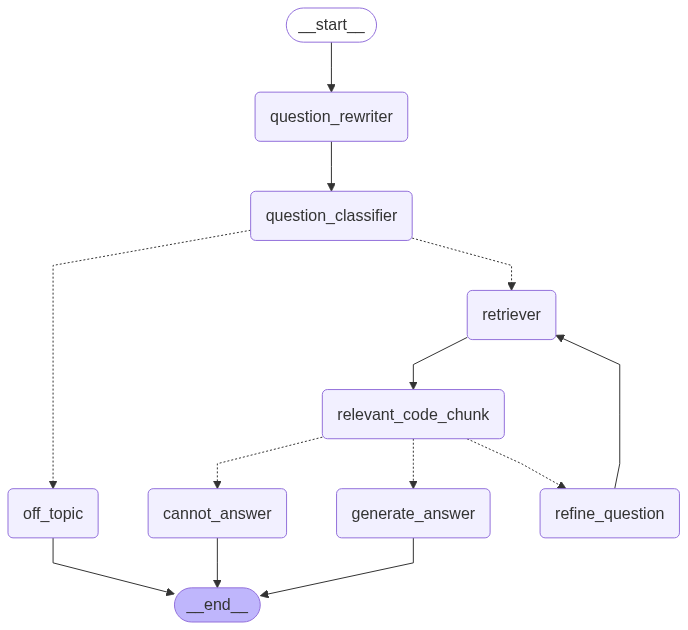

In [11]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)